In [10]:
import asteroid_spinprops.ssolib.dataprep as dprep
import asteroid_spinprops.ssolib.modelfit as mfit
import asteroid_spinprops.ssolib.periodest as pest
import asteroid_spinprops.ssolib.utils as utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import rocks

In [18]:
data_path = os.path.join(os.path.join(os.getcwd(), "data/ephemerides_atlas_ztf_2025.01.parquet"))
sso_keys_path = os.path.join(os.path.join(os.getcwd(), "data/ssoname_keys.pkl"))
sso_keys = pd.read_pickle(sso_keys_path)

In [21]:
name = "2001 UN66"
cdata, reject = dprep.filter_sso_data(sso_name=name, path_to_data=data_path, pqdict=sso_keys, )

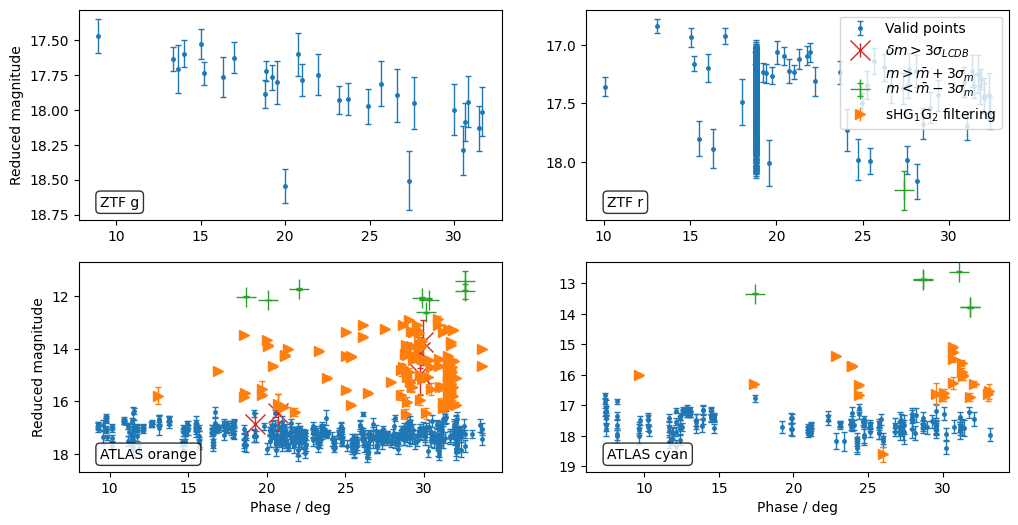

In [23]:
dprep.plot_filtering(cdata, reject)

In [25]:
shgg = mfit.get_fit_params(cdata, "SHG1G2", )

In [27]:
rdf = mfit.make_residuals_df(cdata, shgg)

In [33]:
sg, w, n = pest.get_period_estimate(residuals_dataframe=rdf, p_min=0.03, p_max = 2)

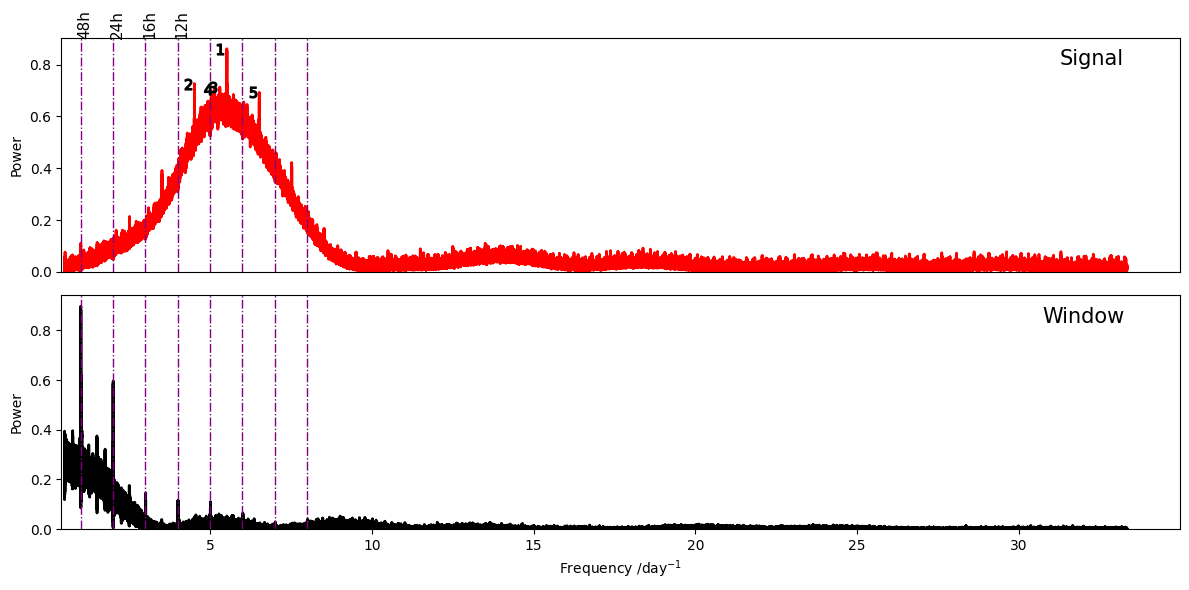

In [35]:
pest.plot_periodograms(sg, w, name)

In [36]:
_, Nbs = pest.perform_residual_resampling(resid_df=rdf)

In [38]:
print(Nbs)

23.0


In [39]:
P0 = 48 / sg[2][0]
P_selected = P0 / 24

In [42]:
sshgg = mfit.get_fit_params(cdata, "SSHG1G2", shg1g2_constrained=True, blind_scan=True, period_in=P_selected)

In [ ]:
# import PyQt5
# %matplotlib qt
mfit.plot_model(cdata, "SSHG1G2", sshgg)

/home/kxenos/Desktop/MAUCA/FYP/asteroid_spinprops/asteroid_spinprops/ssolib/modelfit.py:440: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [ ]:
sshgg["period"] * 24

np.float64(8.700566984614833)

In [76]:
from fink_utils.sso.spins import extract_obliquity
psi = extract_obliquity([name], sshgg["alpha0"], sshgg["delta0"])

In [77]:
psi

array([165.40356908])

In [73]:
utils.oblateness(sshgg["a_b"], sshgg["a_c"])

np.float64(0.5320428346467879)

In [75]:
sshgg["a_c"]

np.float64(3.5530528008845916)